In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("C:/Users/zinan/OneDrive/Documents/drug200.csv")
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [2]:
df.shape

(200, 6)

In [3]:
df.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [5]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [6]:
df.tail()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX
199,40,F,LOW,NORMAL,11.349,drugX


In [7]:
df.describe(include='all')

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
count,200.000000,200,200,200,200.000000,200
unique,NaN,2,3,2,NaN,5
top,NaN,M,HIGH,HIGH,NaN,DrugY
freq,NaN,104,77,103,NaN,91
mean,44.315000,NaN,NaN,NaN,16.084485,NaN
std,16.544315,NaN,NaN,NaN,7.223956,NaN
min,15.000000,NaN,NaN,NaN,6.269000,NaN
25%,31.000000,NaN,NaN,NaN,10.445500,NaN
50%,45.000000,NaN,NaN,NaN,13.936500,NaN
75%,58.000000,NaN,NaN,NaN,19.380000,NaN


In [8]:
df.dtypes

Age              int64
Sex             object
BP              object
Cholesterol     object
Na_to_K        float64
Drug            object
dtype: object

In [9]:
df.isna().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [10]:
from sklearn.preprocessing import LabelEncoder
lab=LabelEncoder()
df['Sex']=lab.fit_transform(df['Sex'])
df['BP']=lab.fit_transform(df['BP'])
df['Cholesterol']=lab.fit_transform(df['Cholesterol'])

In [11]:
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,DrugY
1,47,1,1,0,13.093,drugC
2,47,1,1,0,10.114,drugC
3,28,0,2,0,7.798,drugX
4,61,0,1,0,18.043,DrugY
...,...,...,...,...,...,...
195,56,0,1,0,11.567,drugC
196,16,1,1,0,12.006,drugC
197,52,1,2,0,9.894,drugX
198,23,1,2,1,14.020,drugX


In [12]:
df.dtypes

Age              int64
Sex              int64
BP               int64
Cholesterol      int64
Na_to_K        float64
Drug            object
dtype: object

In [13]:
df1=df['Drug'].value_counts()
df1

Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

<Axes: xlabel='Drug', ylabel='count'>

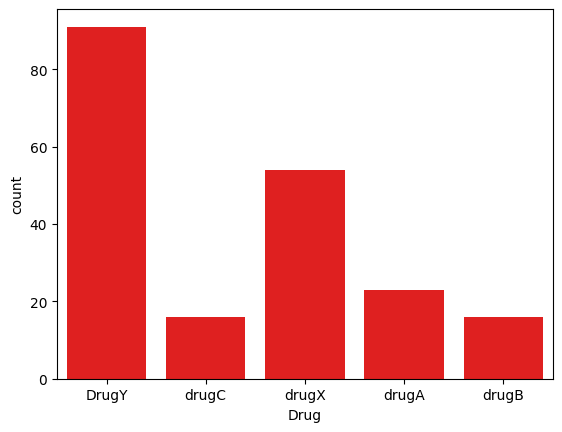

In [14]:
sns.countplot(x=df['Drug'],data=df,color="r")

Text(0.5, 1.0, 'Drug_count')

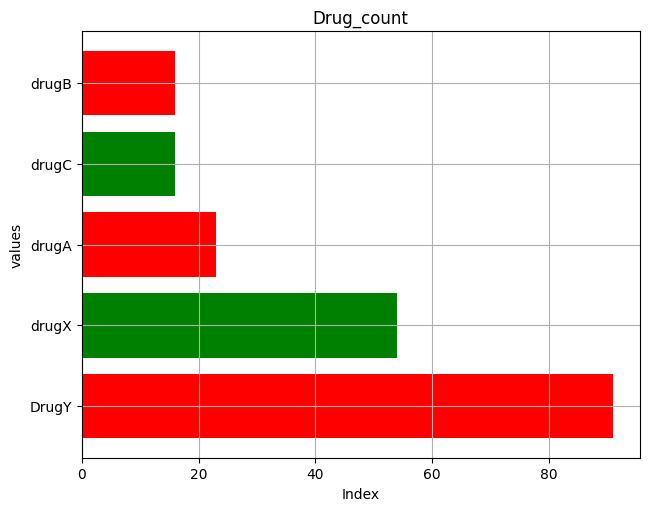

In [15]:
co=['r','g','r','g']
plt.barh(df1.index,df1.values,color=co)
plt.grid()
plt.tight_layout()
plt.xlabel('Index')
plt.ylabel('values')
plt.title('Drug_count')

Text(0.5, 1.0, 'Drug_count_chart')

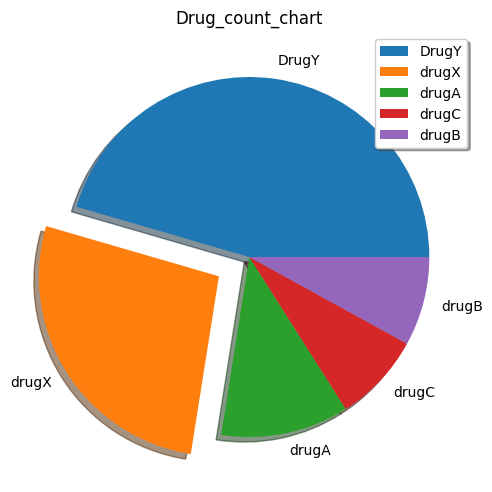

In [16]:
ex=[0,0.2,0,0,0]
plt.pie(df1.values,labels=df1.index,explode=ex,shadow=True)
plt.legend(loc='upper right',shadow=True)
plt.tight_layout()
plt.title('Drug_count_chart')

Text(0.5, 1.0, 'Drug_count')

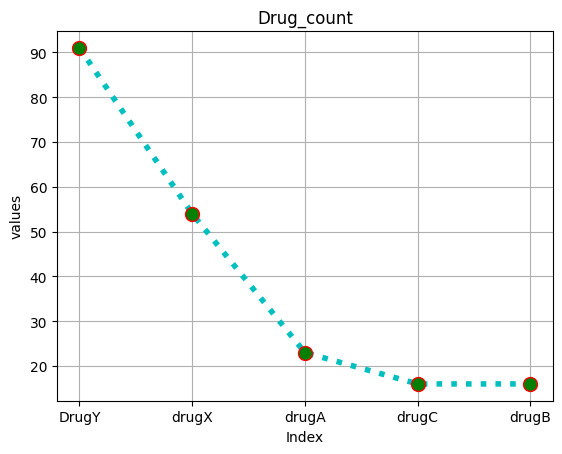

In [17]:
plt.plot(df1.index,df1.values,marker='o',linestyle='dotted',color='c',linewidth=4,mec='r',mfc='g',ms=10)
plt.grid()
plt.xlabel('Index')
plt.ylabel('values')
plt.title('Drug_count')

In [18]:
df.corr(numeric_only=True)

,Age,Sex,BP,Cholesterol,Na_to_K
Age,1.000000,0.102027,0.054212,-0.068234,-0.063119
Sex,0.102027,1.000000,-0.007814,-0.008811,-0.125008
BP,0.054212,-0.007814,1.000000,-0.137552,-0.149312
Cholesterol,-0.068234,-0.008811,-0.137552,1.000000,0.010000
Na_to_K,-0.063119,-0.125008,-0.149312,0.010000,1.000000


<Axes: >

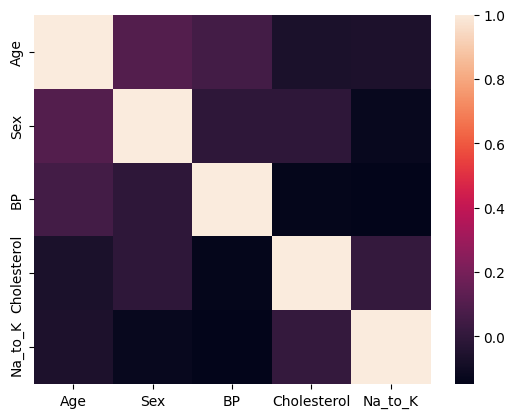

In [19]:
sns.heatmap(df.corr(numeric_only=True))

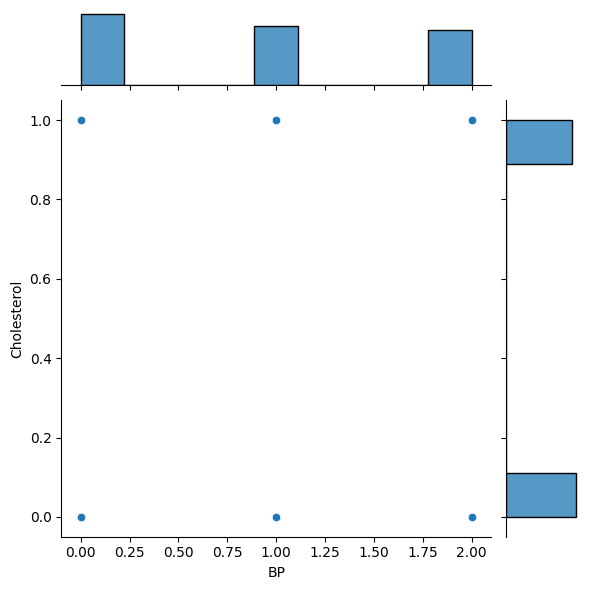

In [20]:
sns.jointplot(x='BP',y='Cholesterol',data=df)

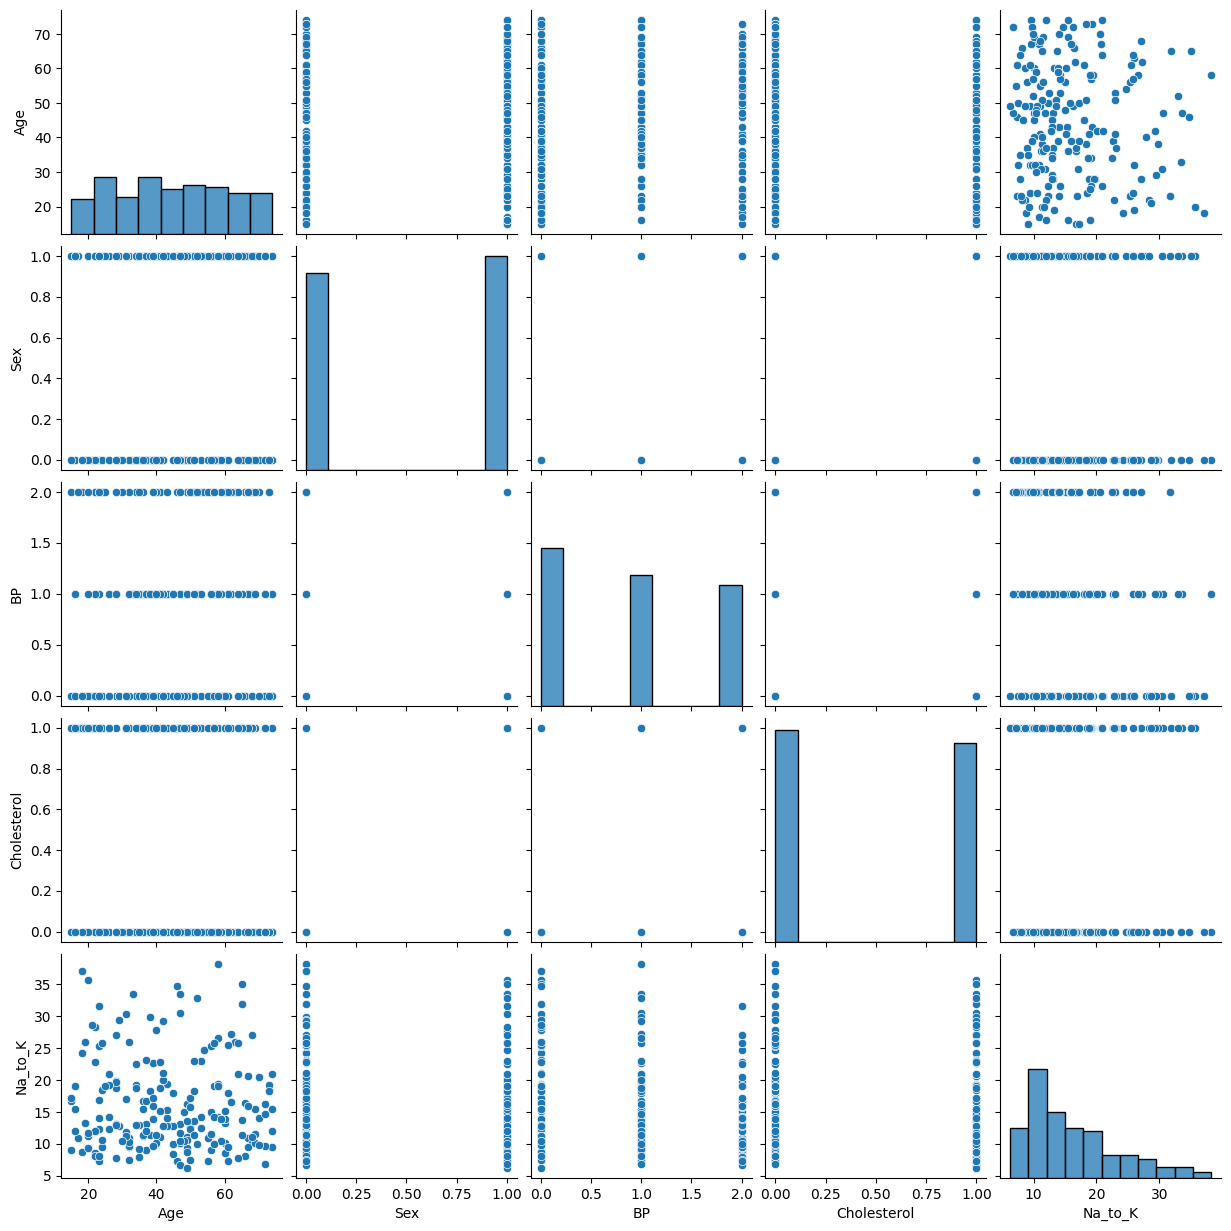

In [21]:
sns.pairplot(df)

In [22]:
x=df.iloc[:,:-1].values
y=df.iloc[:,-1].values
x

array([[23.   ,  0.   ,  0.   ,  0.   , 25.355],
       [47.   ,  1.   ,  1.   ,  0.   , 13.093],
       [47.   ,  1.   ,  1.   ,  0.   , 10.114],
       [28.   ,  0.   ,  2.   ,  0.   ,  7.798],
       [61.   ,  0.   ,  1.   ,  0.   , 18.043],
       [22.   ,  0.   ,  2.   ,  0.   ,  8.607],
       [49.   ,  0.   ,  2.   ,  0.   , 16.275],
       [41.   ,  1.   ,  1.   ,  0.   , 11.037],
       [60.   ,  1.   ,  2.   ,  0.   , 15.171],
       [43.   ,  1.   ,  1.   ,  1.   , 19.368],
       [47.   ,  0.   ,  1.   ,  0.   , 11.767],
       [34.   ,  0.   ,  0.   ,  1.   , 19.199],
       [43.   ,  1.   ,  1.   ,  0.   , 15.376],
       [74.   ,  0.   ,  1.   ,  0.   , 20.942],
       [50.   ,  0.   ,  2.   ,  0.   , 12.703],
       [16.   ,  0.   ,  0.   ,  1.   , 15.516],
       [69.   ,  1.   ,  1.   ,  1.   , 11.455],
       [43.   ,  1.   ,  0.   ,  0.   , 13.972],
       [23.   ,  1.   ,  1.   ,  0.   ,  7.298],
       [32.   ,  0.   ,  0.   ,  1.   , 25.974],
       [57.   ,  1. 

In [23]:
y

array(['DrugY', 'drugC', 'drugC', 'drugX', 'DrugY', 'drugX', 'DrugY',
       'drugC', 'DrugY', 'DrugY', 'drugC', 'DrugY', 'DrugY', 'DrugY',
       'drugX', 'DrugY', 'drugX', 'drugA', 'drugC', 'DrugY', 'DrugY',
       'DrugY', 'DrugY', 'DrugY', 'DrugY', 'DrugY', 'DrugY', 'drugX',
       'DrugY', 'DrugY', 'drugX', 'drugB', 'drugX', 'DrugY', 'drugX',
       'drugX', 'drugA', 'drugX', 'drugX', 'drugX', 'DrugY', 'drugB',
       'DrugY', 'drugX', 'drugX', 'drugX', 'drugA', 'drugC', 'DrugY',
       'DrugY', 'DrugY', 'drugX', 'DrugY', 'DrugY', 'drugB', 'drugC',
       'drugB', 'DrugY', 'drugX', 'DrugY', 'DrugY', 'drugA', 'DrugY',
       'drugX', 'drugB', 'DrugY', 'drugA', 'drugX', 'DrugY', 'DrugY',
       'drugB', 'DrugY', 'drugX', 'DrugY', 'DrugY', 'DrugY', 'drugA',
       'DrugY', 'drugA', 'drugX', 'drugB', 'drugX', 'drugC', 'drugA',
       'drugC', 'drugB', 'drugX', 'DrugY', 'DrugY', 'DrugY', 'DrugY',
       'DrugY', 'DrugY', 'DrugY', 'DrugY', 'drugX', 'DrugY', 'DrugY',
       'DrugY', 'Dru

In [24]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=1)
x_train

array([[67.   ,  1.   ,  2.   ,  1.   ,  9.514],
       [17.   ,  1.   ,  2.   ,  1.   , 10.832],
       [19.   ,  0.   ,  0.   ,  0.   , 13.313],
       [50.   ,  1.   ,  2.   ,  1.   , 15.79 ],
       [43.   ,  1.   ,  0.   ,  0.   , 13.972],
       [22.   ,  0.   ,  2.   ,  0.   ,  8.607],
       [35.   ,  1.   ,  2.   ,  1.   ,  7.845],
       [37.   ,  1.   ,  1.   ,  1.   ,  8.968],
       [23.   ,  1.   ,  2.   ,  0.   , 31.686],
       [29.   ,  1.   ,  0.   ,  0.   , 12.856],
       [68.   ,  0.   ,  0.   ,  1.   , 10.189],
       [47.   ,  0.   ,  1.   ,  0.   , 10.067],
       [36.   ,  0.   ,  0.   ,  1.   , 15.49 ],
       [59.   ,  0.   ,  1.   ,  0.   , 10.444],
       [58.   ,  0.   ,  1.   ,  0.   , 26.645],
       [65.   ,  0.   ,  1.   ,  1.   , 13.769],
       [43.   ,  1.   ,  1.   ,  0.   , 15.376],
       [40.   ,  0.   ,  2.   ,  0.   , 10.103],
       [42.   ,  0.   ,  1.   ,  1.   , 29.271],
       [28.   ,  1.   ,  2.   ,  0.   , 27.064],
       [37.   ,  1. 

In [25]:
x_test

array([[60.   ,  1.   ,  2.   ,  1.   , 10.091],
       [73.   ,  0.   ,  2.   ,  0.   , 19.221],
       [53.   ,  1.   ,  2.   ,  0.   , 14.133],
       [28.   ,  0.   ,  1.   ,  0.   , 13.127],
       [18.   ,  0.   ,  0.   ,  0.   , 37.188],
       [23.   ,  1.   ,  2.   ,  1.   , 14.02 ],
       [36.   ,  1.   ,  1.   ,  1.   , 11.424],
       [61.   ,  0.   ,  1.   ,  0.   , 18.043],
       [45.   ,  1.   ,  1.   ,  0.   , 17.951],
       [51.   ,  0.   ,  1.   ,  1.   , 23.003],
       [45.   ,  1.   ,  1.   ,  1.   , 10.017],
       [23.   ,  1.   ,  1.   ,  0.   ,  7.298],
       [34.   ,  0.   ,  0.   ,  1.   , 19.199],
       [50.   ,  0.   ,  2.   ,  1.   , 17.211],
       [50.   ,  1.   ,  0.   ,  0.   ,  7.49 ],
       [32.   ,  0.   ,  0.   ,  1.   , 10.292],
       [34.   ,  0.   ,  1.   ,  1.   , 12.923],
       [46.   ,  1.   ,  2.   ,  1.   ,  7.285],
       [55.   ,  0.   ,  0.   ,  0.   , 10.977],
       [34.   ,  1.   ,  0.   ,  0.   , 18.703],
       [67.   ,  1. 

In [26]:
y_train

array(['drugX', 'drugX', 'drugA', 'DrugY', 'drugA', 'drugX', 'drugX',
       'drugX', 'DrugY', 'drugA', 'drugB', 'drugC', 'DrugY', 'drugC',
       'DrugY', 'drugX', 'DrugY', 'drugX', 'DrugY', 'DrugY', 'DrugY',
       'DrugY', 'drugX', 'DrugY', 'drugA', 'DrugY', 'drugC', 'drugX',
       'drugA', 'drugX', 'DrugY', 'drugA', 'drugB', 'drugB', 'drugX',
       'drugX', 'drugC', 'drugX', 'drugX', 'DrugY', 'DrugY', 'DrugY',
       'DrugY', 'drugX', 'drugC', 'drugB', 'drugB', 'drugA', 'DrugY',
       'drugX', 'DrugY', 'drugC', 'DrugY', 'DrugY', 'drugC', 'drugX',
       'DrugY', 'DrugY', 'drugA', 'DrugY', 'DrugY', 'DrugY', 'drugA',
       'drugX', 'DrugY', 'DrugY', 'DrugY', 'drugX', 'DrugY', 'drugC',
       'drugX', 'drugA', 'drugX', 'drugA', 'DrugY', 'DrugY', 'DrugY',
       'DrugY', 'drugX', 'DrugY', 'drugB', 'drugX', 'drugX', 'DrugY',
       'drugB', 'DrugY', 'drugB', 'DrugY', 'DrugY', 'drugB', 'DrugY',
       'DrugY', 'drugA', 'drugX', 'DrugY', 'drugX', 'drugA', 'DrugY',
       'drugC', 'Dru

In [27]:
y_test

array(['drugX', 'DrugY', 'drugX', 'drugC', 'DrugY', 'drugX', 'drugX',
       'DrugY', 'DrugY', 'DrugY', 'drugX', 'drugC', 'DrugY', 'DrugY',
       'drugA', 'drugA', 'drugX', 'drugX', 'drugB', 'DrugY', 'drugX',
       'drugX', 'drugX', 'DrugY', 'drugB', 'drugX', 'drugX', 'DrugY',
       'drugC', 'drugX', 'drugC', 'DrugY', 'DrugY', 'DrugY', 'drugA',
       'DrugY', 'drugA', 'DrugY', 'DrugY', 'DrugY', 'drugB', 'DrugY',
       'DrugY', 'drugX', 'drugB', 'DrugY', 'drugX', 'drugX', 'DrugY',
       'drugB', 'DrugY', 'DrugY', 'DrugY', 'DrugY', 'DrugY', 'DrugY',
       'drugX', 'drugX', 'drugX', 'drugB'], dtype=object)

In [28]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred

array(['drugX', 'drugX', 'drugX', 'DrugY', 'DrugY', 'DrugY', 'drugX',
       'drugC', 'DrugY', 'DrugY', 'drugX', 'drugX', 'DrugY', 'drugX',
       'drugB', 'drugA', 'DrugY', 'drugX', 'drugB', 'DrugY', 'drugX',
       'drugX', 'drugX', 'drugC', 'drugB', 'drugX', 'drugX', 'DrugY',
       'drugX', 'drugX', 'drugX', 'DrugY', 'DrugY', 'DrugY', 'drugA',
       'DrugY', 'drugA', 'DrugY', 'DrugY', 'DrugY', 'drugB', 'DrugY',
       'drugA', 'drugX', 'drugB', 'DrugY', 'DrugY', 'DrugY', 'DrugY',
       'drugA', 'DrugY', 'DrugY', 'DrugY', 'DrugY', 'DrugY', 'drugX',
       'drugX', 'DrugY', 'drugX', 'drugA'], dtype='<U5')

In [29]:
y_test

array(['drugX', 'DrugY', 'drugX', 'drugC', 'DrugY', 'drugX', 'drugX',
       'DrugY', 'DrugY', 'DrugY', 'drugX', 'drugC', 'DrugY', 'DrugY',
       'drugA', 'drugA', 'drugX', 'drugX', 'drugB', 'DrugY', 'drugX',
       'drugX', 'drugX', 'DrugY', 'drugB', 'drugX', 'drugX', 'DrugY',
       'drugC', 'drugX', 'drugC', 'DrugY', 'DrugY', 'DrugY', 'drugA',
       'DrugY', 'drugA', 'DrugY', 'DrugY', 'DrugY', 'drugB', 'DrugY',
       'DrugY', 'drugX', 'drugB', 'DrugY', 'drugX', 'drugX', 'DrugY',
       'drugB', 'DrugY', 'DrugY', 'DrugY', 'DrugY', 'DrugY', 'DrugY',
       'drugX', 'drugX', 'drugX', 'drugB'], dtype=object)

In [30]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score
cm=confusion_matrix(y_test,y_pred)
cm

array([[21,  1,  0,  2,  3],
       [ 0,  3,  1,  0,  0],
       [ 0,  2,  4,  0,  0],
       [ 1,  0,  0,  0,  3],
       [ 5,  0,  0,  0, 14]])

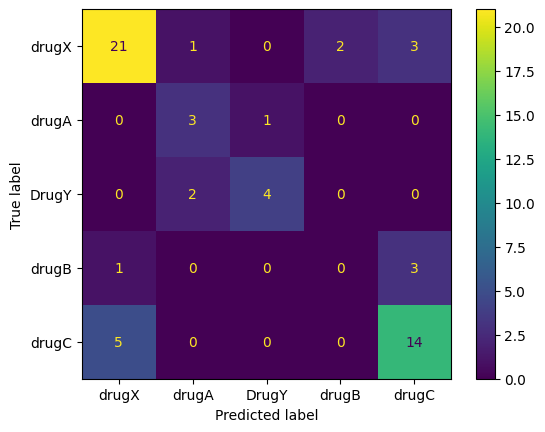

In [31]:
lab=['drugX','drugA','DrugY','drugB','drugC']
cmd=ConfusionMatrixDisplay(cm,display_labels=lab)
cmd.plot()

In [32]:
score=accuracy_score(y_test,y_pred)*100
score

70.0

In [33]:
from sklearn.metrics import classification_report
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

       DrugY       0.78      0.78      0.78        27
       drugA       0.50      0.75      0.60         4
       drugB       0.80      0.67      0.73         6
       drugC       0.00      0.00      0.00         4
       drugX       0.70      0.74      0.72        19

    accuracy                           0.70        60
   macro avg       0.56      0.59      0.56        60
weighted avg       0.69      0.70      0.69        60

